# PubMed Abstract Sentence Classification

A feedforward neural network baseline for classifying sentences in biomedical abstracts.

## 1. Environment Setup

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT_numbers_replaced_with_at_sign/dev.csv
/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT_numbers_replaced_with_at_sign/test.txt
/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT_numbers_replaced_with_at_sign/dev.txt
/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT_numbers_replaced_with_at_sign/train.csv
/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT_numbers_replaced_with_at_sign/test.csv
/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT_numbers_replaced_with_at_sign/train/train.txt
/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT/dev.csv
/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT/test.txt
/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT/dev.txt
/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT/train.csv
/kaggle/input/datasets/matthewjanse

## 2. Imports

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.tokenize import word_tokenize

## 3. Data Loading and Exploration

Text(0.5, 1.0, 'Stats for classes')

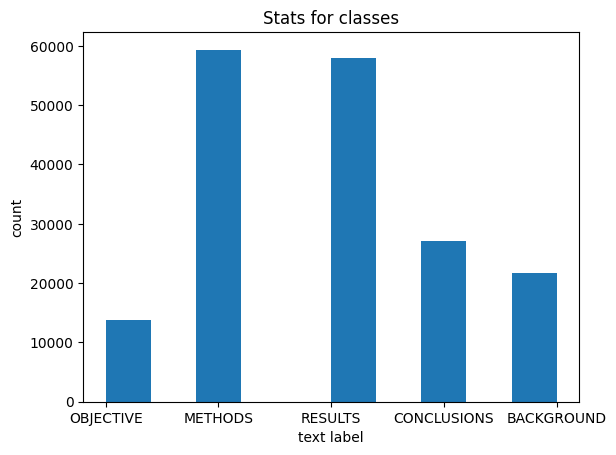

In [23]:
df = pd.read_csv("/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_20k_RCT/train.csv")
validation_df = pd.read_csv("/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_20k_RCT/dev.csv")
test_df = pd.read_csv("/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_20k_RCT/test.csv")

plt.hist(df["target"])
plt.xlabel("text label")
plt.ylabel("count")
plt.title("Stats for classes")

## 4. Text Preprocessing

In [ ]:
import re

num_pattern = re.compile(r"^[+-]?\d+(?:[\.,]\d+)?(?:[eE][+-]?\d+)?$")


def preprocess_text(data):
    data["tokens"] = data["abstract_text"].str.lower()
    data["tokens"] = data["tokens"].apply(
        lambda words: word_tokenize(words)
    )
    data["tokens"] = data["tokens"].apply(
        lambda words: [
            "<num>" if num_pattern.fullmatch(word) else word for word in words
        ]
    )
    return data


df = preprocess_text(df)
validation_df = preprocess_text(validation_df)
test_df = preprocess_text(test_df)

## 5. Vocabulary Construction and Analysis

In [ ]:
vocabulary = {token for sentence in df["tokens"] for token in sentence}
vocabulary.add("<unk>")
vocabulary.add("<pad>")

word_to_idx = {word : i for i, word in enumerate(vocabulary)}

label2idx = {
    "BACKGROUND": 0,
    "OBJECTIVE": 1,
    "METHODS": 2,
    "RESULTS": 3,
    "CONCLUSIONS": 4,
}

percentile_95 = df["tokens"].str.len().quantile(0.95)
print(percentile_95)

In [5]:
from collections import Counter

word_counts = Counter(
    token
    for sentence in df["tokens"]
    for token in sentence
)

In [7]:
for threshold in [1, 2, 3, 5, 10]:
    count = sum(
        frequency <= threshold
        for frequency in word_counts.values()
    )
    print(f"Frequency <= {threshold}: {count}")

Frequency <= 1: 40858
Frequency <= 2: 52167
Frequency <= 3: 58506
Frequency <= 5: 65861
Frequency <= 10: 73771


In [8]:
filtered_vocabulary = vocabulary.copy()
for word in vocabulary:
    if word_counts[word] <=1:
        filtered_vocabulary.remove(word)

len(filtered_vocabulary)

47981

In [ ]:
def replace_rare_tokens(data):
    data["tokens"] = data["tokens"].apply(
        lambda words: [
            word if word in filtered_vocabulary and word != "<unk>" else "<unk>" for word in words
        ]
    )
    return data


df = replace_rare_tokens(df)
validation_df = replace_rare_tokens(validation_df)
test_df = replace_rare_tokens(test_df)

## 6. Hyperparameters and Target Encoding

In [11]:
min_frequency = 2
max_length = 55
batch_size = 64
embed_size = 128

pad_idx = word_to_idx["<pad>"]

model_hyperparameters = {
    "batch_size": batch_size,
    "embed_dim": embed_size,
    "hidden_dim": 128,
    "freeze_embeddings": False,
    "num_classes": 5,
    "dropout_rate": 0.3
}

In [ ]:
def encode_targets(data):
    data["encoded_target"] = data["target"].apply(
        lambda target: [
            label2idx[target]
        ]
    )
    return data[["tokens", "encoded_target"]]


train_data = encode_targets(df)
validation_data = encode_targets(validation_df)
test_data = encode_targets(test_df)

## 7. Dataset and DataLoaders

In [ ]:
from torch.utils.data import Dataset, DataLoader 
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


def tokens_to_idx(sentence, word_to_idx=word_to_idx):
    unk_idx = word_to_idx["<unk>"]
    return [word_to_idx.get(word, unk_idx) for word in sentence]


class PubMedDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sentence = torch.as_tensor(tokens_to_idx(self.data.iloc[idx, 0]), dtype = torch.long)
        label = torch.as_tensor(self.data.iloc[idx, 1], dtype = torch.long).squeeze()
        return sentence, label


def collate_fn(batch, max_length=max_length, pad_idx=pad_idx):
    x, y = zip(*batch)
    x = [sentence[:max_length] for sentence in x]
    x_padded = pad_sequence(
        x,
        batch_first=True,
        padding_value=pad_idx,
    )
    y_padded = torch.stack(y)
    mask = x_padded != pad_idx
    return x_padded, y_padded, mask


def create_dataloader(data, shuffle=False):
    return DataLoader(
        PubMedDataset(data),
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn,
    )


loader = create_dataloader(train_data, shuffle=True)
validation_loader = create_dataloader(validation_data)
test_loader = create_dataloader(test_data)

## 8. Model Architecture

In [16]:
class AbstractSentenceClassifier(nn.Module):

  def __init__(self, hyperparameters, vocab_size = len(vocabulary), pad_ix=pad_idx):
    super(AbstractSentenceClassifier, self).__init__()

    self.embed_dim = hyperparameters["embed_dim"]
    self.hidden_dim = hyperparameters["hidden_dim"]
    self.freeze_embeddings = hyperparameters["freeze_embeddings"]
    self.num_classes = hyperparameters["num_classes"]
    self.dropout_rate = hyperparameters["dropout_rate"]

    self.embed_layer = nn.Embedding(vocab_size, self.embed_dim, padding_idx=pad_ix)
    if self.freeze_embeddings:
      self.embed_layer.weight.requires_grad = False

    self.hidden_layer = nn.Sequential(
      nn.Linear(self.embed_dim, self.hidden_dim),
      nn.Tanh(),
      nn.Dropout(self.dropout_rate)
    )
    
    self.logits = nn.Linear(self.hidden_dim, self.num_classes)

  def forward(self, inputs, mask):
    embedded_input = self.embed_layer(inputs)
    masked_embeds = (embedded_input * mask.unsqueeze(-1)).sum(dim=1)
    
    lengths = (
        mask.sum(dim=1, keepdim=True)
        .clamp(min=1)
    )
      
    sentence_vector = masked_embeds / lengths
    
    output = self.logits(self.hidden_layer(sentence_vector))
    
    return output

## 9. Training Configuration

In [17]:
learning_rate = 1e-2
weight_decay = 1e-4

model = AbstractSentenceClassifier(model_hyperparameters)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay) 
criterion = nn.CrossEntropyLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

## 10. Training and Validation Utilities

In [ ]:
def train_epoch(criterion, optimizer, model, loader, device):
    
  model.train()
  total_loss = 0
    
  for batch_inputs, batch_labels, batch_masks in loader:

    
      
    batch_inputs = batch_inputs.to(device)
    batch_labels = batch_labels.to(device)
    batch_masks = batch_masks.to(device)
    
    optimizer.zero_grad()
    outputs = model(batch_inputs, batch_masks)
      
    loss = criterion(outputs, batch_labels)
    
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
      
  return total_loss / len(loader)

def evaluate(criterion, model, loader, device):
    model.eval()

    total_loss = 0.0
    total_examples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch_inputs, batch_labels, batch_masks in loader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)
            batch_masks = batch_masks.to(device)

            logits = model(batch_inputs, batch_masks)
            loss = criterion(logits, batch_labels)

            batch_size = batch_labels.size(0)

            # CrossEntropyLoss по умолчанию возвращает среднее по batch
            total_loss += loss.item() * batch_size
            total_examples += batch_size

            predictions = logits.argmax(dim=1)

            all_labels.extend(batch_labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    average_loss = total_loss / total_examples

    metrics = {
        "loss": average_loss,
        "accuracy": accuracy_score(all_labels, all_predictions),
        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0,
        ),
    }

    return metrics, all_labels, all_predictions

def train(
    criterion,
    optimizer,
    model,
    train_loader,
    validation_loader,
    device,
    num_epochs,
):
    best_macro_f1 = 0.0

    for epoch in range(num_epochs):
        train_loss = train_epoch(
            criterion,
            optimizer,
            model,
            train_loader,
            device,
        )

        val_metrics, val_labels, val_predictions = evaluate(
            criterion,
            model,
            validation_loader,
            device,
        )

        print(
            f"Epoch {epoch + 1:03d} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_metrics['loss']:.4f} | "
            f"accuracy: {val_metrics['accuracy']:.4f} | "
            f"macro-F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = val_metrics["macro_f1"]

            torch.save(
                model.state_dict(),
                "best_model.pt",
            )

## 11. Model Training

In [ ]:
num_epochs = 15

train(
    criterion,
    optimizer,
    model,
    loader,
    validation_loader,
    device,
    num_epochs,
)

## 12. Validation Evaluation

In [ ]:
model.load_state_dict(
    torch.load("best_model.pt", map_location=device)
)

val_metrics, val_labels, val_predictions = evaluate(
    criterion,
    model,
    validation_loader,
    device,
)

In [ ]:
label_names = [
    "BACKGROUND",
    "OBJECTIVE",
    "METHODS",
    "RESULTS",
    "CONCLUSIONS",
]

In [ ]:
print(
    classification_report(
        val_labels,
        val_predictions,
        target_names=label_names,
        zero_division=0,
    )
)

In [ ]:
cm = confusion_matrix(
    val_labels,
    val_predictions,
    labels=range(len(label_names)),
)

print(cm)

## 13. Test Evaluation

In [ ]:
test_metrics, test_labels, test_predictions = evaluate(
    criterion,
    model,
    test_loader,
    device,
)

test_metrics